```
Feature Maps (CNN)
        ↓
Flatten
        ↓
Vector
        ↓
Dense Layer (MLP)
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.convolution import Convolution2D
from src.activation import ReLU
from src.pooling import MaxPooling2D
from src.flatten import Flatten

from src.utils import (
    load_image,
    show_image,
    plot_feature_maps
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("08 - FLATTEN")
print("=" * 60)

CNN FROM SCRATCH
08 - FLATTEN


1. waht is flatten

In [3]:
feature_map = np.arange(
    16
).reshape(
    1,
    4,
    4
)

print(feature_map)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]
  [12 13 14 15]]]


In [4]:
print(
    "Shape:",
    feature_map.shape
)

Shape: (1, 4, 4)


In [5]:
flatten = Flatten()

vector = flatten.forward(
    feature_map
)

print(vector)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [6]:
print(
    "Shape:",
    vector.shape
)

Shape: (16,)


```
Flatten simply reshapes:

(C,H,W)

↓

(N,)
```

2. Manual Example

In [7]:
example = np.array(
[
[
[1,2],
[3,4]
]
]
)

print(example)

[[[1 2]
  [3 4]]]


In [8]:
flatten = Flatten()

output = flatten.forward(
    example
)

print(output)

[1 2 3 4]


```
No computation.

No weights.

No bias.

Only reshape.
```

3. Flatten Formula

```
Input Shape

(C,H,W)

↓

Output Shape

(C × H × W,)
```

In [9]:
C = 16
H = 8
W = 8

N = C * H * W

print(
    f"Flatten Size = {N}"
)

Flatten Size = 1024


4. Real CNN Pipeline

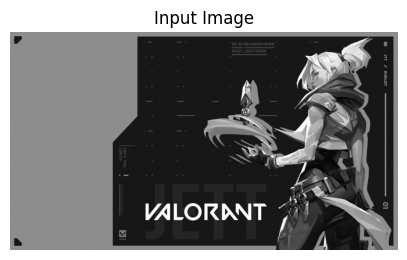

In [10]:
image = load_image(
    "../data/sample1.jpg",
    grayscale=True
)

show_image(
    image,
    "Input Image"
)

In [11]:
# Conv

conv = Convolution2D(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(
    image
)

print(
    feature_maps.shape
)

(8, 1080, 1920)


In [12]:
# ReLU

relu = ReLU()

feature_maps = relu.forward(
    feature_maps
)

In [13]:
# Pooling

pool = MaxPooling2D(
    pool_size=2,
    stride=2
)

feature_maps = pool.forward(
    feature_maps
)

print(
    feature_maps.shape
)

(8, 540, 960)


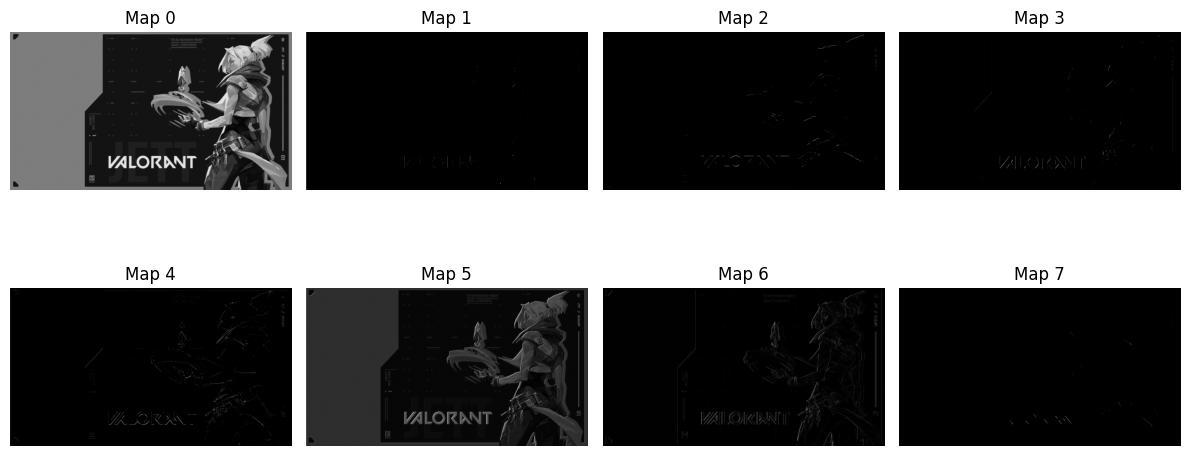

In [14]:
plot_feature_maps(
    feature_maps,
    max_maps=8
)

5. Flatten CNN Output

In [15]:
flatten = Flatten()

vector = flatten.forward(
    feature_maps
)

In [16]:
print(
    "Feature Map Shape:",
    feature_maps.shape
)

print(
    "Flatten Shape:",
    vector.shape
)

Feature Map Shape: (8, 540, 960)
Flatten Shape: (4147200,)


In [17]:
print(
    vector[:20]
)

[208.64958677 208.64958677 208.64958677 208.64958677 208.64958677
 208.64958677 208.64958677 208.64958677 208.64958677 208.64958677
 208.64958677 208.64958677 208.64958677 208.64958677 208.64958677
 208.64958677 208.64958677 208.64958677 208.64958677 208.64958677]


In [ ]:
print(
    f"Vector Length: {len(vector):,}"
)

6. Why Dense Needs Flatten

```
Dense Layer performs:

z = Wx + b

where x must be a vector.

Feature Maps cannot be multiplied
directly by a weight matrix.

Flatten solves this problem.

Feature Maps

(8,540,960)

↓

Flatten

(4,147,200)

↓

Dense
```

7. Visualizing Memory Growth

In [18]:
sizes = [
    (1,28,28),
    (8,28,28),
    (16,14,14),
    (32,7,7)
]

for shape in sizes:

    total = np.prod(shape)

    print(
        f"{shape} -> {total}"
    )

(1, 28, 28) -> 784
(8, 28, 28) -> 6272
(16, 14, 14) -> 3136
(32, 7, 7) -> 1568


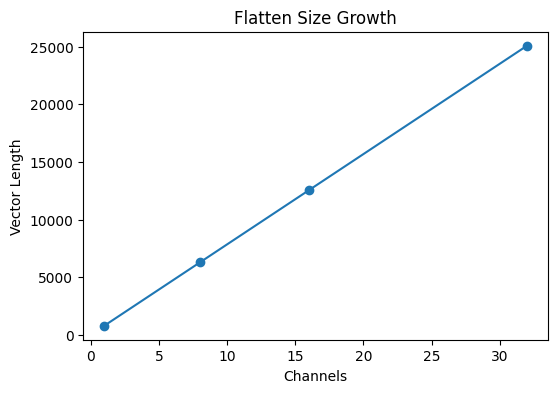

In [19]:
channels = [1,8,16,32]
sizes = []

for c in channels:

    sizes.append(
        c*28*28
    )

plt.figure(figsize=(6,4))

plt.plot(
    channels,
    sizes,
    marker="o"
)

plt.title(
    "Flatten Size Growth"
)

plt.xlabel(
    "Channels"
)

plt.ylabel(
    "Vector Length"
)

plt.show()

8. Backpropagation Intuition

```
Forward:

(C,H,W)

↓

(N,)
```

```
Backward:

(N,)

↓

(C,H,W)
```

In [20]:
example = np.arange(
    16
).reshape(
    1,
    4,
    4
)

flatten = Flatten()

vector = flatten.forward(
    example
)

restored = vector.reshape(
    example.shape
)

print(
    restored
)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]
  [12 13 14 15]]]


9. Parameter Count

Flatten Parameters = 0

- No weights

- No bias

- No trainable parameters